<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Product_ID                     30 non-null     object 
 1   Product_Name                   30 non-null     object 
 2   Category                       30 non-null     object 
 3   Units_Sold_Last_30_Days        30 non-null     int64  
 4   Current_Stock                  30 non-null     int64  
 5   Reorder_Level                  30 non-null     int64  
 6   Lead_Time_Days                 30 non-null     int64  
 7   Unit_Cost                      30 non-null     int64  
 8   Supplier_Rating                30 non-null     float64
 9   Warehouse_Utilization_Percent  30 non-null     int64  
 10  Demand_Next_Week               30 non-null     int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 2.7+ KB


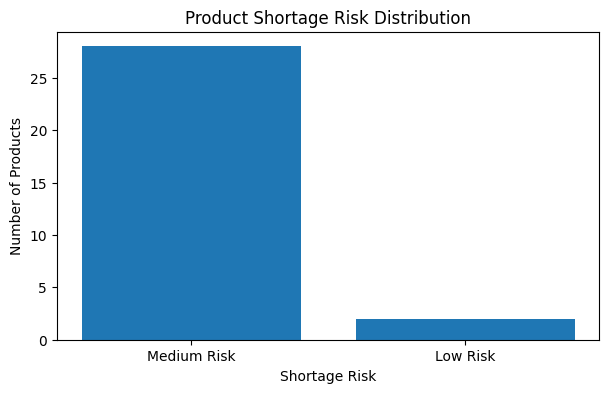

Average Demand by Category:
Category
Grocery          337.142857
Snacks           243.333333
Beverage         217.500000
Bakery           200.000000
Dairy            180.000000
Home Care        155.000000
Personal Care    151.250000
Stationery       120.000000
Electronics       90.000000
Name: Units_Sold_Last_30_Days, dtype: float64
Average Current Stock by Category:
Category
Grocery          94.285714
Snacks           75.666667
Beverage         70.500000
Bakery           66.000000
Dairy            58.500000
Home Care        51.000000
Personal Care    50.000000
Stationery       50.000000
Electronics      40.000000
Name: Current_Stock, dtype: float64


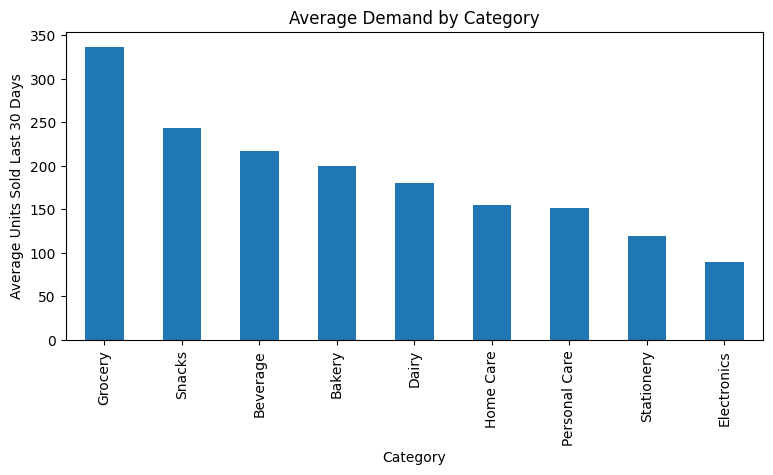

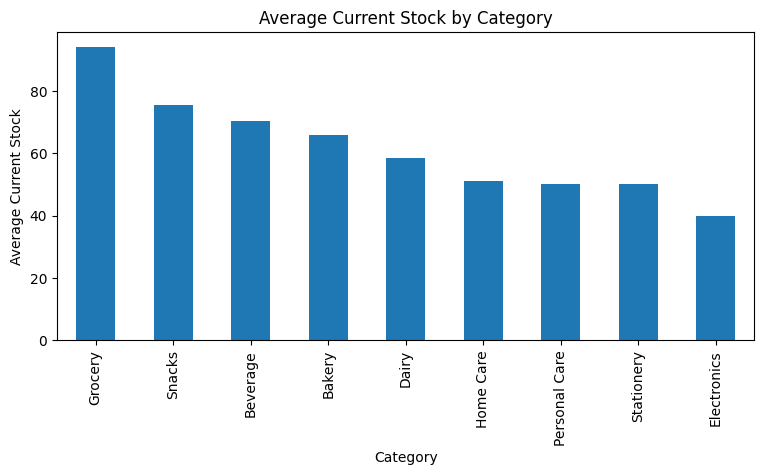

,Product_ID,Product_Name,Current_Stock,Reorder_Level,Stock_Gap,Shortage_Risk
26,P027,Cheese,49,46,3,Medium Risk
29,P030,Tissue Pack,44,40,4,Medium Risk
22,P023,Cleaner,46,42,4,Medium Risk
25,P026,Butter,54,50,4,Medium Risk
2,P003,Cooking Oil,85,80,5,Medium Risk
7,P008,Shampoo,45,40,5,Medium Risk
6,P007,Soap,55,50,5,Medium Risk
5,P006,Milk Powder,60,55,5,Medium Risk
12,P013,Coffee,65,60,5,Medium Risk
8,P009,Toothpaste,50,45,5,Medium Risk


In [1]:
# Cell 1: Import required libraries
# Cell 1
# Import all required libraries for data handling, visualization,
# preprocessing, machine learning, and model evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Cell 2: Create the operations analytics dataset
# Cell 2
# Create a sample operations dataset
# Each row represents one product being tracked by the operations team

data = {
    "Product_ID": ["P001", "P002", "P003", "P004", "P005", "P006", "P007", "P008", "P009", "P010",
                   "P011", "P012", "P013", "P014", "P015", "P016", "P017", "P018", "P019", "P020",
                   "P021", "P022", "P023", "P024", "P025", "P026", "P027", "P028", "P029", "P030"],

    "Product_Name": ["Rice", "Wheat Flour", "Cooking Oil", "Sugar", "Tea", "Milk Powder", "Soap", "Shampoo", "Toothpaste", "Biscuits",
                     "Detergent", "Salt", "Coffee", "Noodles", "Juice", "Chips", "Dal", "Spices", "Battery", "Notebook",
                     "Pen", "Handwash", "Cleaner", "Face Wash", "Bread", "Butter", "Cheese", "Eggs", "Water Bottle", "Tissue Pack"],

    "Category": ["Grocery", "Grocery", "Grocery", "Grocery", "Beverage", "Dairy", "Personal Care", "Personal Care", "Personal Care", "Snacks",
                 "Home Care", "Grocery", "Beverage", "Snacks", "Beverage", "Snacks", "Grocery", "Grocery", "Electronics", "Stationery",
                 "Stationery", "Home Care", "Home Care", "Personal Care", "Bakery", "Dairy", "Dairy", "Dairy", "Beverage", "Home Care"],

    "Units_Sold_Last_30_Days": [450, 380, 320, 290, 210, 180, 160, 140, 150, 260,
                                175, 300, 190, 240, 220, 230, 340, 280, 90, 110,
                                130, 165, 145, 155, 200, 170, 160, 210, 250, 135],

    "Current_Stock": [120, 100, 85, 95, 70, 60, 55, 45, 50, 80,
                      58, 90, 65, 72, 68, 75, 88, 82, 40, 52,
                      48, 56, 46, 50, 66, 54, 49, 71, 79, 44],

    "Reorder_Level": [100, 90, 80, 85, 60, 55, 50, 40, 45, 70,
                      50, 75, 60, 65, 60, 68, 80, 75, 35, 45,
                      40, 50, 42, 45, 58, 50, 46, 65, 70, 40],

    "Lead_Time_Days": [5, 6, 7, 5, 4, 6, 5, 6, 5, 4,
                       6, 5, 4, 3, 4, 3, 6, 5, 8, 7,
                       6, 5, 6, 5, 3, 4, 4, 3, 4, 5],

    "Unit_Cost": [55, 42, 135, 48, 220, 310, 35, 145, 80, 25,
                  120, 20, 260, 18, 95, 22, 90, 75, 45, 30,
                  10, 85, 110, 140, 32, 210, 280, 8, 20, 60],

    "Supplier_Rating": [4.5, 4.2, 4.0, 4.3, 4.6, 4.1, 3.9, 4.0, 4.2, 4.4,
                        4.1, 4.5, 4.6, 4.3, 4.2, 4.0, 4.4, 4.5, 3.8, 4.1,
                        4.0, 4.2, 4.1, 4.0, 4.3, 4.2, 4.1, 4.4, 4.5, 4.0],

    "Warehouse_Utilization_Percent": [78, 76, 82, 75, 70, 68, 66, 65, 64, 72,
                                      69, 74, 71, 73, 70, 72, 79, 77, 60, 62,
                                      63, 67, 66, 65, 69, 68, 67, 71, 73, 64],

    "Demand_Next_Week": [115, 98, 90, 88, 72, 62, 54, 46, 49, 82,
                         57, 92, 67, 75, 70, 78, 94, 85, 30, 38,
                         42, 55, 48, 50, 68, 56, 52, 73, 81, 45]
}

df = pd.DataFrame(data)

# Display first 5 rows of the dataset
df.head()


# Cell 3: View the full dataset
# Cell 3
# Display the complete operations dataset

df


# Cell 4: Check dataset information
# Cell 4
# Check column names, data types, and non-null values

df.info()


# Cell 5: Check for missing values
# Cell 5
# Verify whether there are any missing values in the dataset

df.isnull().sum()


# Cell 6: Basic statistical summary
# Cell 6
# Generate summary statistics for numeric columns

df.describe()


# Cell 7: Create stock gap metric
# Cell 7
# Calculate the gap between current stock and reorder level
# Positive gap means stock is above reorder level
# Negative gap means stock is below reorder level

df["Stock_Gap"] = df["Current_Stock"] - df["Reorder_Level"]

# Display updated dataset
df.head()


# Cell 8: Create inventory turnover proxy
# Cell 8
# Create a simple inventory turnover proxy using units sold and current stock
# Higher value means faster movement of inventory

df["Inventory_Turnover_Proxy"] = df["Units_Sold_Last_30_Days"] / df["Current_Stock"]

# Display updated dataset
df.head()


# Cell 9: Create shortage risk category
# Cell 9
# Create a business-friendly shortage risk category
# High Risk -> stock is close to or below reorder level and lead time is high
# Medium Risk -> moderate stock situation
# Low Risk -> comfortable stock position

def shortage_risk(row):
    if row["Current_Stock"] <= row["Reorder_Level"] and row["Lead_Time_Days"] >= 6:
        return "High Risk"
    elif row["Current_Stock"] <= row["Reorder_Level"] + 10:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Shortage_Risk"] = df.apply(shortage_risk, axis=1)

# Display updated dataset
df.head()


# Cell 10: Count products by shortage risk
# Cell 10
# Count how many products fall into each shortage risk category

df["Shortage_Risk"].value_counts()


# Cell 11: Visualize shortage risk distribution
# Cell 11
# Plot shortage risk distribution

risk_counts = df["Shortage_Risk"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(risk_counts.index, risk_counts.values)
plt.title("Product Shortage Risk Distribution")
plt.xlabel("Shortage Risk")
plt.ylabel("Number of Products")
plt.show()


# Cell 12: Identify high-demand products
# Cell 12
# Display products with highest historical demand

df.sort_values(by="Units_Sold_Last_30_Days", ascending=False).head(10)


# Cell 13: Identify low-stock products
# Cell 13
# Display products with lowest current stock

df.sort_values(by="Current_Stock", ascending=True).head(10)


# Cell 14: Identify products below or near reorder level
# Cell 14
# Display products that require monitoring because they are near reorder level

df[df["Current_Stock"] <= df["Reorder_Level"] + 5][[
    "Product_ID",
    "Product_Name",
    "Current_Stock",
    "Reorder_Level",
    "Lead_Time_Days",
    "Shortage_Risk"
]]


# Cell 15: Analyze average demand by category
# Cell 15
# Calculate average units sold for each product category

avg_demand_by_category = df.groupby("Category")["Units_Sold_Last_30_Days"].mean().sort_values(ascending=False)

print("Average Demand by Category:")
print(avg_demand_by_category)


# Cell 16: Analyze average stock by category
# Cell 16
# Calculate average stock for each category

avg_stock_by_category = df.groupby("Category")["Current_Stock"].mean().sort_values(ascending=False)

print("Average Current Stock by Category:")
print(avg_stock_by_category)


# Cell 17: Visualize average demand by category
# Cell 17
# Plot average demand by product category

avg_demand_by_category.plot(kind="bar", figsize=(9, 4))
plt.title("Average Demand by Category")
plt.xlabel("Category")
plt.ylabel("Average Units Sold Last 30 Days")
plt.show()


# Cell 18: Visualize average stock by category
# Cell 18
# Plot average current stock by category

avg_stock_by_category.plot(kind="bar", figsize=(9, 4))
plt.title("Average Current Stock by Category")
plt.xlabel("Category")
plt.ylabel("Average Current Stock")
plt.show()


# Cell 19: Analyze stock gap by product
# Cell 19
# Sort products by stock gap to identify the most critical items

df.sort_values(by="Stock_Gap", ascending=True)[[
    "Product_ID",
    "Product_Name",
    "Current_Stock",
    "Reorder_Level",
    "Stock_Gap",
    "Shortage_Risk"
]].head(10)

Features:
   Category_Encoded  Units_Sold_Last_30_Days  Current_Stock  Reorder_Level  \
0                 4                      450            120            100   
1                 4                      380            100             90   
2                 4                      320             85             80   
3                 4                      290             95             85   
4                 1                      210             70             60   

   Lead_Time_Days  Unit_Cost  Supplier_Rating  Warehouse_Utilization_Percent  
0               5         55              4.5                             78  
1               6         42              4.2                             76  
2               7        135              4.0                             82  
3               5         48              4.3                             75  
4               4        220              4.6                             70  

Target:
0    115
1     98
2     90
3     88
4 

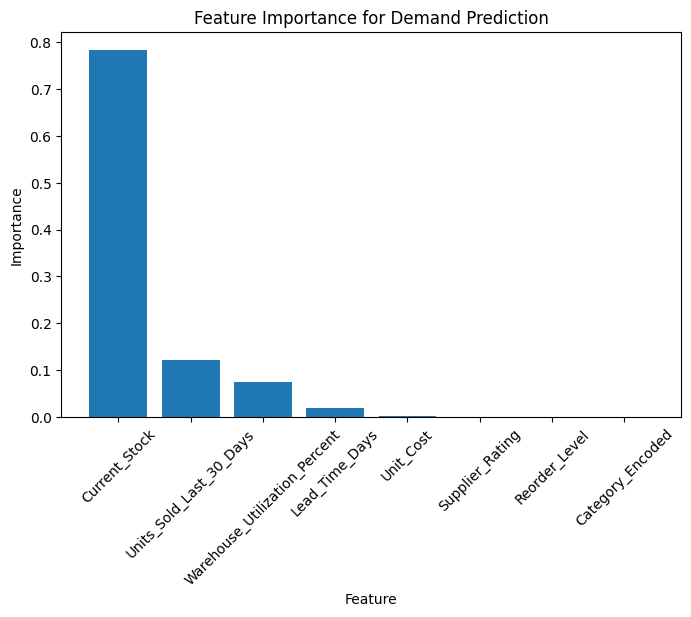

Predicted Demand for Next Week: 94.0
Total Products: 30
High Risk Products: 0
Medium Risk Products: 28
Low Risk Products: 2
Most Common Reorder Action: Plan Reorder Soon
Top Demand Driver: Current_Stock
Highest Priority Product: Rice


In [2]:
# Cell 20: Create reorder recommendation
# Cell 20
# Create a simple reorder recommendation
# Urgent Reorder -> High Risk
# Plan Reorder Soon -> Medium Risk
# Monitor Normally -> Low Risk

def reorder_action(risk):
    if risk == "High Risk":
        return "Urgent Reorder"
    elif risk == "Medium Risk":
        return "Plan Reorder Soon"
    else:
        return "Monitor Normally"

df["Reorder_Action"] = df["Shortage_Risk"].apply(reorder_action)

# Display updated dataset
df[["Product_ID", "Product_Name", "Shortage_Risk", "Reorder_Action"]].head(10)


# Cell 21: Count reorder actions
# Cell 21
# Count how many products fall into each shortage risk category

df["Reorder_Action"].value_counts()


# Cell 22: Encode categorical columns
# Cell 22
# Convert text-based categorical columns into numeric values
# This is needed for the demand prediction model

le_category = LabelEncoder()

df["Category_Encoded"] = le_category.fit_transform(df["Category"])

# Display updated dataset
df.head()


# Cell 23: Select features and target for demand prediction
# Cell 23
# Define the input features and target variable
# Target = Demand_Next_Week

X = df[[
    "Category_Encoded",
    "Units_Sold_Last_30_Days",
    "Current_Stock",
    "Reorder_Level",
    "Lead_Time_Days",
    "Unit_Cost",
    "Supplier_Rating",
    "Warehouse_Utilization_Percent"
]]

y = df["Demand_Next_Week"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())


# Cell 24: Split data into training and testing sets
# Cell 24
# Split the data into training and testing sets
# 80% data is used for training and 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


# Cell 25: Train the demand prediction model
# Cell 25
# Train a Decision Tree Regressor to predict next week's demand

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

print("Demand prediction model trained successfully.")


# Cell 26: Make predictions on test data
# Cell 26
# Predict next week's demand for the test dataset

y_pred = model.predict(X_test)

print("Predicted Demand Values:")
print(y_pred)


# Cell 27: Evaluate the model using MAE
# Cell 27
# Calculate Mean Absolute Error
# This tells us the average absolute prediction error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)


# Cell 28: Evaluate the model using MSE
# Cell 28
# Calculate Mean Squared Error
# This penalizes larger prediction errors more strongly

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)


# Cell 29: Evaluate the model using R-squared
# Cell 29
# Calculate R-squared score
# This tells us how much variation in demand is explained by the model

r2 = r2_score(y_test, y_pred)

print("R-squared (R2 Score):", r2)


# Cell 30: Compare actual and predicted demand
# Cell 30
# Create a comparison table of actual and predicted demand values

comparison_df = pd.DataFrame({
    "Actual_Demand": y_test.values,
    "Predicted_Demand": y_pred
})

comparison_df


# Cell 31: Identify feature importance
# Cell 31
# Check which features are most important in demand prediction

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance


# Cell 32: Visualize feature importance
# Cell 32
# Plot feature importance for demand prediction

plt.figure(figsize=(8, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance for Demand Prediction")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()


# Cell 33: Predict demand for a new product situation
# Cell 33
# Predict next week's demand for a new operational scenario
# Example:
# Category = Grocery
# Units_Sold_Last_30_Days = 360
# Current_Stock = 92
# Reorder_Level = 85
# Lead_Time_Days = 6
# Unit_Cost = 60
# Supplier_Rating = 4.4
# Warehouse_Utilization_Percent = 77

new_product = pd.DataFrame([{
    "Category_Encoded": le_category.transform(["Grocery"])[0],
    "Units_Sold_Last_30_Days": 360,
    "Current_Stock": 92,
    "Reorder_Level": 85,
    "Lead_Time_Days": 6,
    "Unit_Cost": 60,
    "Supplier_Rating": 4.4,
    "Warehouse_Utilization_Percent": 77
}])

predicted_demand = model.predict(new_product)

print("Predicted Demand for Next Week:", predicted_demand[0])


# Cell 34: Create operational priority score
# Cell 34
# Create a simple operational priority score
# Higher score means the product needs more operational attention

df["Operational_Priority_Score"] = (
    df["Units_Sold_Last_30_Days"] * 0.4 +
    (100 - df["Current_Stock"]) * 0.3 +
    df["Lead_Time_Days"] * 5 +
    (5 - df["Supplier_Rating"]) * 10
)

# Display updated dataset
df[["Product_ID", "Product_Name", "Operational_Priority_Score"]].head()


# Cell 35: Identify top priority products
# Cell 35
# Sort products by operational priority score
# Higher score indicates higher urgency for operational review

df.sort_values(by="Operational_Priority_Score", ascending=False)[[
    "Product_ID",
    "Product_Name",
    "Units_Sold_Last_30_Days",
    "Current_Stock",
    "Lead_Time_Days",
    "Supplier_Rating",
    "Operational_Priority_Score"
]].head(10)


# Cell 36: View final operations analytics dashboard table
# Cell 36
# Display final important operational columns for managerial review

df[[
    "Product_ID",
    "Product_Name",
    "Category",
    "Units_Sold_Last_30_Days",
    "Current_Stock",
    "Reorder_Level",
    "Stock_Gap",
    "Lead_Time_Days",
    "Shortage_Risk",
    "Reorder_Action",
    "Demand_Next_Week",
    "Operational_Priority_Score"
]]


# Cell 37: Print final operations insights summary
# Cell 37
# Print a concise operations intelligence summary

print("Total Products:", len(df))
print("High Risk Products:", (df["Shortage_Risk"] == "High Risk").sum())
print("Medium Risk Products:", (df["Shortage_Risk"] == "Medium Risk").sum())
print("Low Risk Products:", (df["Shortage_Risk"] == "Low Risk").sum())
print("Most Common Reorder Action:", df["Reorder_Action"].mode()[0])
print("Top Demand Driver:", feature_importance.iloc[0]["Feature"])
print("Highest Priority Product:", df.sort_values(by='Operational_Priority_Score', ascending=False).iloc[0]["Product_Name"])